In [1]:
# Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load dataset

In [8]:
df = pd.read_csv(r"C:\Users\J.Shiva\OneDrive\Attachments\credit-risk-prediction\data\raw\loan_payments.csv")
df.head()

,id,member_id,loan_amount,funded_amount,funded_amount_inv,term,int_rate,instalment,grade,sub_grade,...,recoveries,collection_recovery_fee,last_payment_date,last_payment_amount,next_payment_date,last_credit_pull_date,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type
0,38676116,41461848,8000,8000.0,8000.0,36 months,7.49,248.82,A,A4,...,0.0,0.0,Jan-2022,248.82,Feb-2022,Jan-2022,0.0,5.0,1,INDIVIDUAL
1,38656203,41440010,13200,13200.0,13200.0,36 months,6.99,407.52,A,A3,...,0.0,0.0,Jan-2022,407.52,Feb-2022,Jan-2022,0.0,NaN,1,INDIVIDUAL
2,38656154,41439961,16000,16000.0,16000.0,36 months,7.49,497.63,A,A4,...,0.0,0.0,Oct-2021,12850.16,NaN,Oct-2021,0.0,NaN,1,INDIVIDUAL
3,38656128,41439934,15000,15000.0,15000.0,36 months,14.31,514.93,C,C4,...,0.0,0.0,Jun-2021,13899.67,NaN,Jun-2021,0.0,NaN,1,INDIVIDUAL
4,38656121,41439927,15000,15000.0,15000.0,36 months,6.03,456.54,A,A1,...,0.0,0.0,Jan-2022,456.54,Feb-2022,Jan-2022,0.0,NaN,1,INDIVIDUAL


In [9]:
# Checking shape and basic info

In [10]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

Shape: (54231, 43)

Column Names:
 ['id', 'member_id', 'loan_amount', 'funded_amount', 'funded_amount_inv', 'term', 'int_rate', 'instalment', 'grade', 'sub_grade', 'employment_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_date', 'loan_status', 'payment_plan', 'purpose', 'dti', 'delinq_2yrs', 'earliest_credit_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_accounts', 'total_accounts', 'out_prncp', 'out_prncp_inv', 'total_payment', 'total_payment_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_payment_date', 'last_payment_amount', 'next_payment_date', 'last_credit_pull_date', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type']


In [11]:
# Checking target column distribution

In [12]:
print(df['loan_status'].value_counts())
print("\nPercentage:\n", df['loan_status'].value_counts(normalize=True).mul(100).round(2))

loan_status
Fully Paid                                             27037
Current                                                19268
Charged Off                                             5571
Does not meet the credit policy. Status:Fully Paid       984
Late (31-120 days)                                       580
Does not meet the credit policy. Status:Charged Off      368
In Grace Period                                          265
Late (16-30 days)                                        106
Default                                                   52
Name: count, dtype: int64

Percentage:
 loan_status
Fully Paid                                             49.86
Current                                                35.53
Charged Off                                            10.27
Does not meet the credit policy. Status:Fully Paid      1.81
Late (31-120 days)                                      1.07
Does not meet the credit policy. Status:Charged Off     0.68
In Grace Period      

In [13]:
# Creating binary target column

In [14]:
default_statuses = [
    'Charged Off',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Default',
    'In Grace Period'
]

df['target'] = df['loan_status'].apply(lambda x: 1 if x in default_statuses else 0)

print(df['target'].value_counts())
print("\nDefault Rate:", round(df['target'].mean() * 100, 2), "%")

target
0    47289
1     6942
Name: count, dtype: int64

Default Rate: 12.8 %


In [15]:
print(df.dtypes)

id                               int64
member_id                        int64
loan_amount                      int64
funded_amount                  float64
funded_amount_inv              float64
term                               str
int_rate                       float64
instalment                     float64
grade                              str
sub_grade                          str
employment_length                  str
home_ownership                     str
annual_inc                     float64
verification_status                str
issue_date                         str
loan_status                        str
payment_plan                       str
purpose                            str
dti                            float64
delinq_2yrs                      int64
earliest_credit_line               str
inq_last_6mths                   int64
mths_since_last_delinq         float64
mths_since_last_record         float64
open_accounts                    int64
total_accounts           

In [16]:
null_df = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df[null_df['Null Count'] > 0].sort_values('Null %', ascending=False))

                             Null Count  Null %
mths_since_last_record            48050   88.60
mths_since_last_major_derog       46732   86.17
next_payment_date                 32608   60.13
mths_since_last_delinq            31002   57.17
int_rate                           5169    9.53
term                               4772    8.80
funded_amount                      3007    5.54
employment_length                  2118    3.91
last_payment_date                    73    0.13
collections_12_mths_ex_med           51    0.09
last_credit_pull_date                 7    0.01


In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
# Checking statistical summary of numerical columns

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,54231.0,7.621797e+06,9.571362e+06,55521.00,759433.000,7084590.00,8.860616e+06,3.867612e+07
member_id,54231.0,8.655350e+06,1.031281e+07,70694.00,958772.000,8709873.00,1.052714e+07,4.146185e+07
loan_amount,54231.0,1.333308e+04,8.082197e+03,500.00,7000.000,12000.00,1.800000e+04,3.500000e+04
funded_amount,51224.0,1.322951e+04,8.019018e+03,500.00,7000.000,12000.00,1.800000e+04,3.500000e+04
funded_amount_inv,54231.0,1.295262e+04,8.099474e+03,0.00,6700.000,11300.00,1.800000e+04,3.500000e+04
int_rate,49062.0,1.350733e+01,4.392893e+00,5.42,10.370,13.16,1.620000e+01,2.606000e+01
instalment,54231.0,4.000140e+02,2.389200e+02,15.67,224.205,347.15,5.275500e+02,1.407010e+03
annual_inc,54231.0,7.222085e+04,5.158934e+04,3300.00,45000.000,61000.00,8.600000e+04,2.039784e+06
dti,54231.0,1.586709e+01,7.623124e+00,0.00,10.200,15.60,2.126000e+01,3.991000e+01
delinq_2yrs,54231.0,2.417990e-01,7.067062e-01,0.00,0.000,0.00,0.000000e+00,1.800000e+01


In [20]:
# Plotting target class distribution

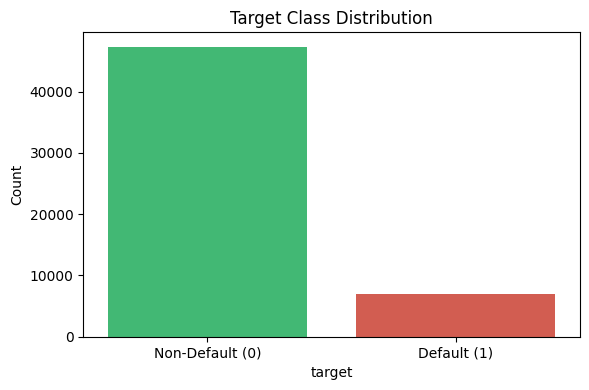

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Target Class Distribution')
plt.xticks([0, 1], ['Non-Default (0)', 'Default (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [22]:
# Plotting key numerical features distribution by target

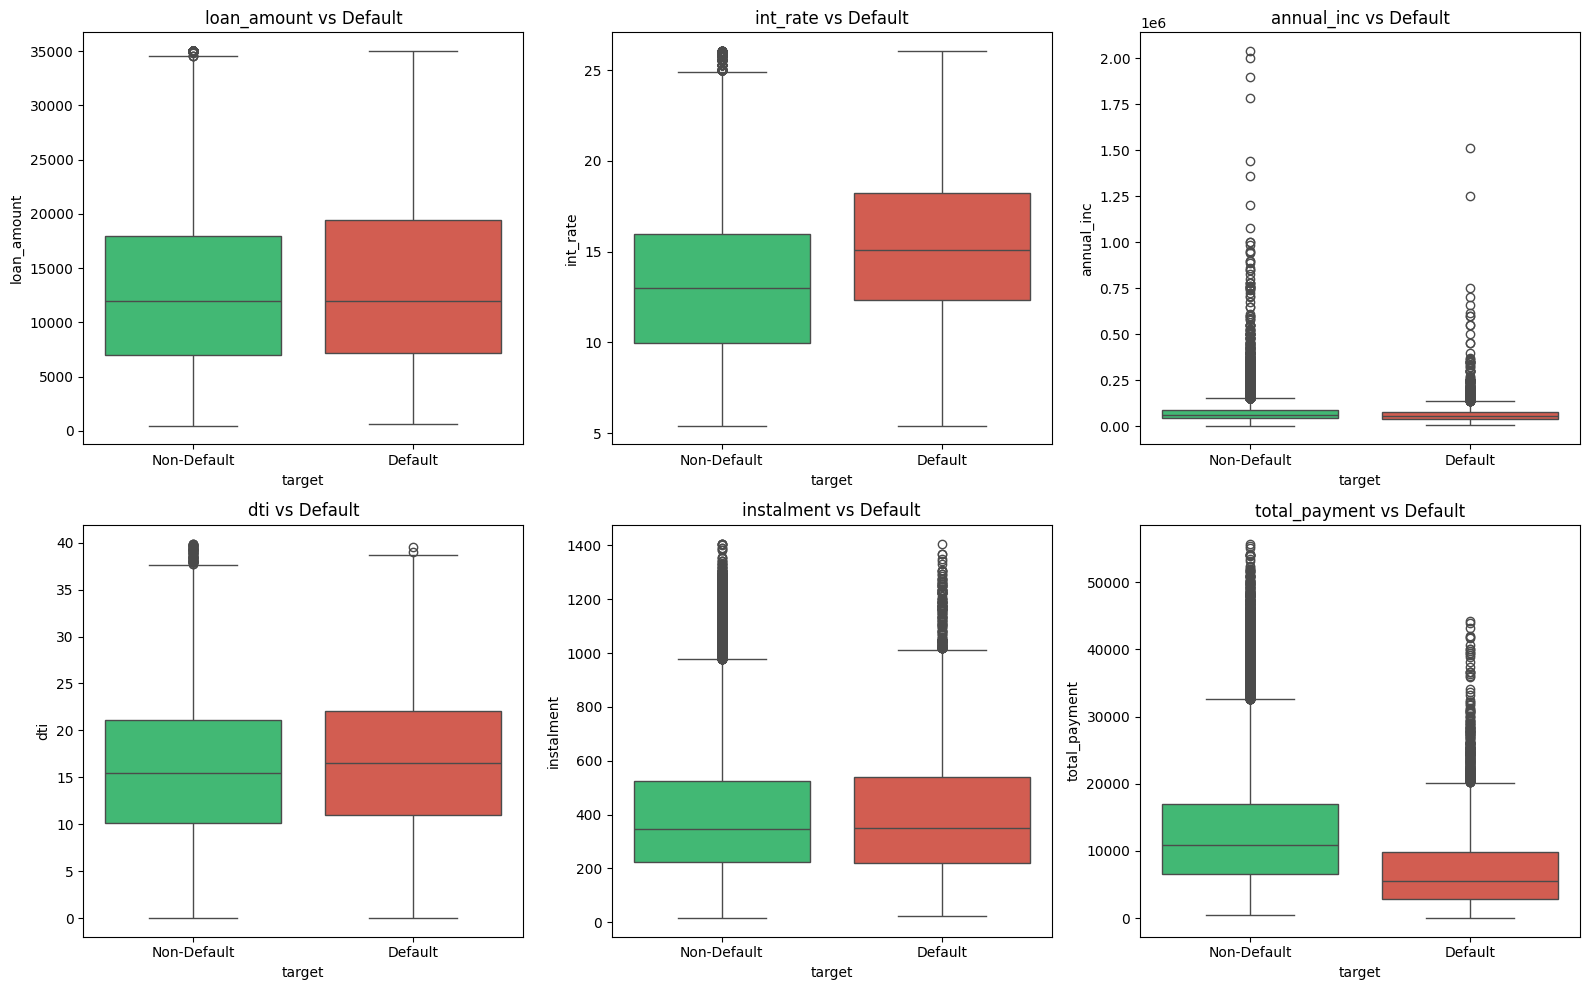

In [23]:
num_cols = ['loan_amount', 'int_rate', 'annual_inc', 'dti', 'instalment', 'total_payment']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='target', data=df, y=col, palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} vs Default')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Default', 'Default'])

plt.tight_layout()
plt.show()

In [ ]:
## Numerical Features vs Default - Observations
- **int_rate** — defaults have clearly higher interest rates, strong predictor
- **loan_amount** — similar distribution, weak separator
- **annual_inc** — extreme outliers on both sides, needs outlier treatment
- **dti** — defaults slightly higher, mild signal
- **instalment** — similar, weak separator
- **total_payment** — non-defaults paid much more (obvious — they completed loans)

In [24]:
# Plotting categorical features default rate

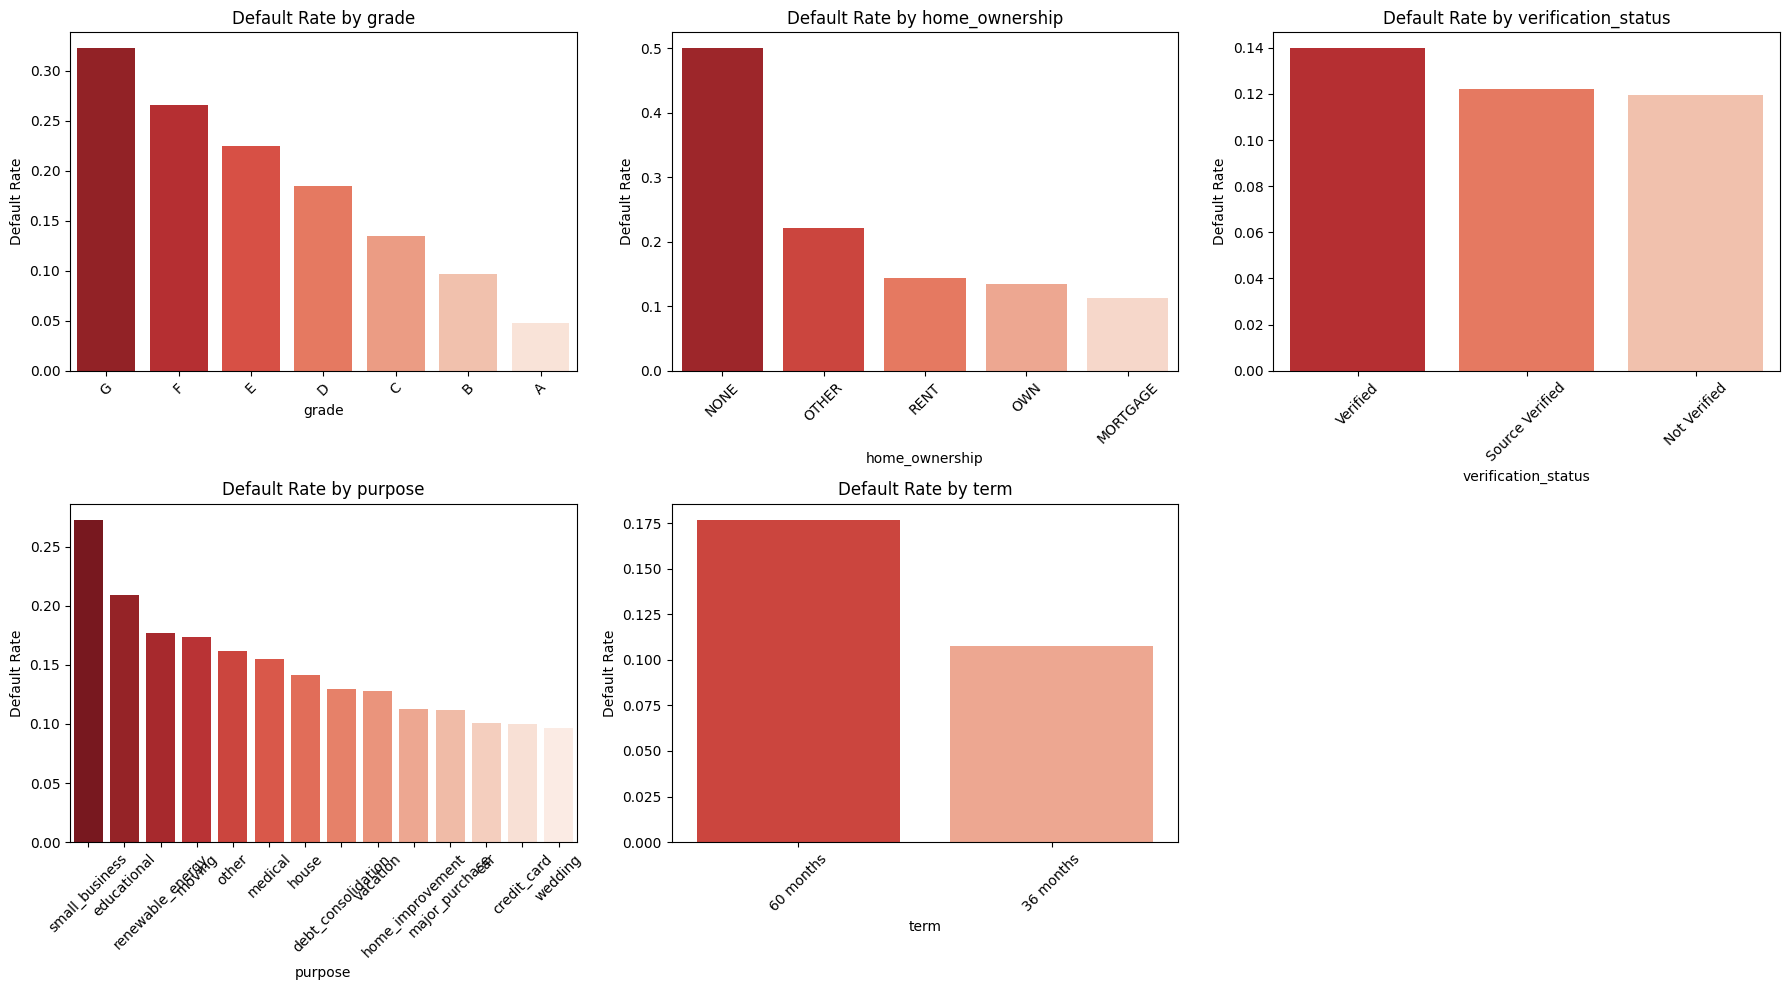

In [25]:
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    sns.barplot(x=default_rate.index, y=default_rate.values, palette='Reds_r', ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=45)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

## Categorical Features vs Default - Observations
- **grade** — clear pattern, G grade has 32% default rate vs A grade ~5%, very strong predictor
- **home_ownership** — NONE category has 50% default rate, MORTGAGE is safest
- **verification_status** — surprisingly, Verified has highest default rate (counter-intuitive)
- **purpose** — small_business and educational loans default most (~30%), wedding lowest
- **term** — 60 month loans default at 17.5% vs 36 month at 10.5%, term length matters

In [27]:
# Plotting correlation heatmap of numerical features

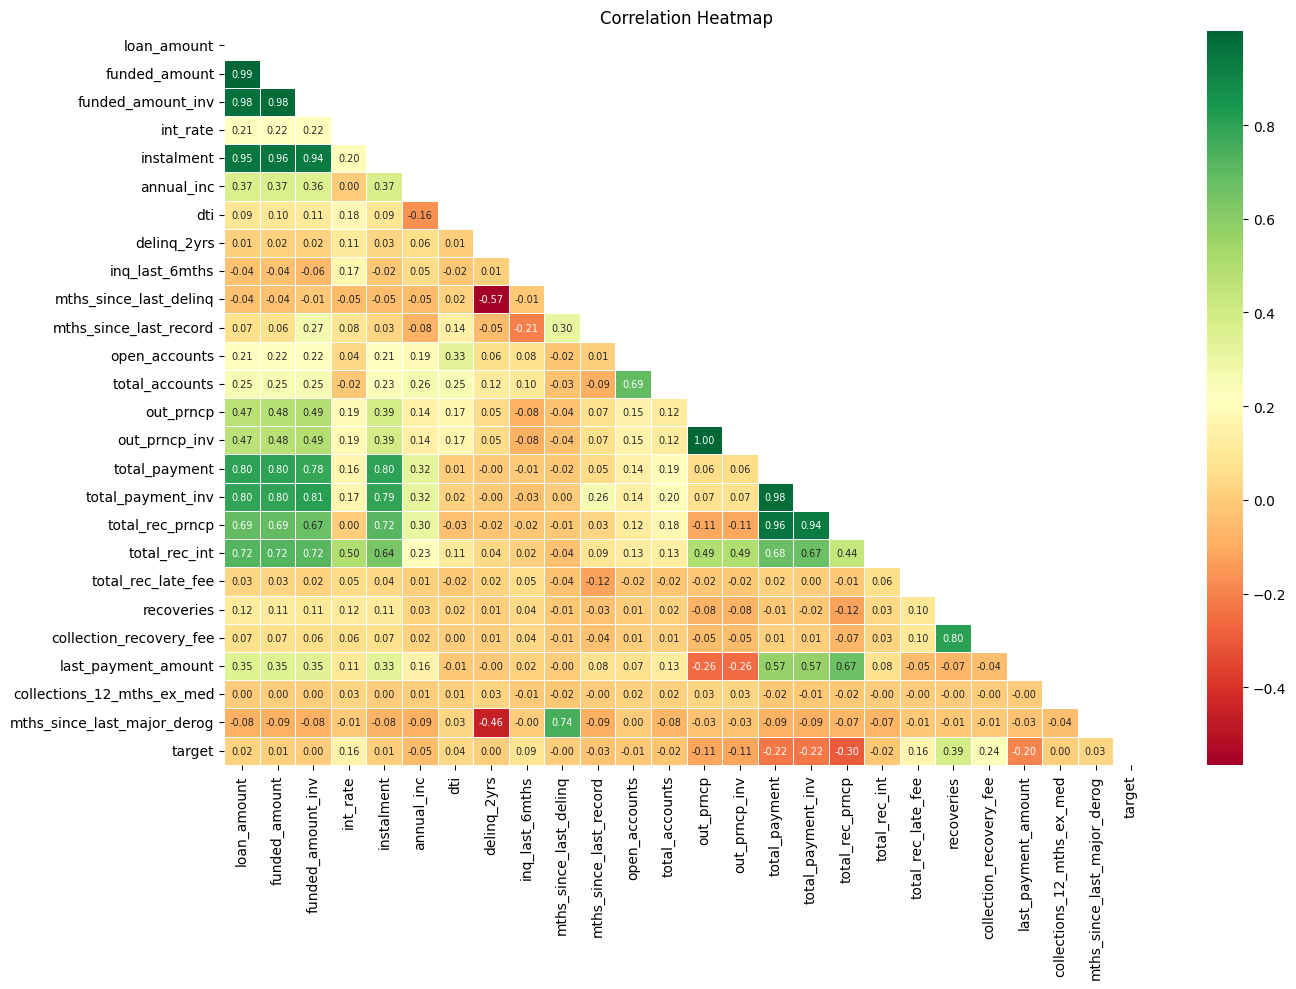

In [28]:
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id', 'member_id', 'policy_code'])
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Correlation Heatmap - Observations
- **loan_amount, funded_amount, funded_amount_inv, instalment** — highly correlated (0.95+), multicollinearity risk, will drop redundant ones
- **total_payment, total_rec_prncp, total_payment_inv** — highly correlated (0.90+), keep only one
- **out_prncp and out_prncp_inv** — correlation of 1.0, exact duplicates, drop one
- **int_rate vs target** — 0.39 correlation, strongest numerical predictor of default
- **recoveries vs target** — 0.39, also strong but may cause data leakage (post-default info)
- **total_payment vs target** — -0.23, non-defaults paid more